# Machine Learning Assignment: Customer Segmentation & Purchase Prediction

**Name:** Sarbani Karmakar  
**Date:** 28/01/2026


## Part 1: Data Exploration and Preprocessing

### 1.1 Load and Inspect the Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

pd.set_option('display.max_columns', None)


In [2]:
df = pd.read_csv("customer_data.csv")
df.head(10)


,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0
5,CUST000249,36.0,Female,Tier 2,Silver,160.15,6,26.69,39.0,8.0,3,8.96,0
6,CUST003299,32.0,Male,Tier 2,Gold,3440.79,17,202.40,29.0,29.0,6,304.40,1
7,CUST000107,37.0,Female,Tier 1,Silver,505.17,6,84.20,51.0,15.0,4,16.93,0
8,CUST000280,26.0,Female,Tier 3,Silver,2476.96,9,275.22,44.0,10.0,4,71.01,0
9,CUST001282,27.0,NaN,Tier 1,Silver,404.24,12,33.69,56.0,17.0,8,26.07,0


In [3]:
df.shape


(5025, 13)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5025 non-null   object 
 1   age                           4723 non-null   float64
 2   gender                        4724 non-null   object 
 3   city_tier                     5025 non-null   object 
 4   membership_type               5025 non-null   object 
 5   total_spend                   5025 non-null   float64
 6   num_transactions              5025 non-null   int64  
 7   avg_transaction_value         5025 non-null   float64
 8   days_since_last_purchase      4723 non-null   float64
 9   num_visits                    4724 non-null   float64
 10  product_categories_purchased  5025 non-null   int64  
 11  discount_used                 5025 non-null   float64
 12  high_value_customer           5025 non-null   int64  
dtypes: 

In [5]:
df.describe()


,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
count,4723.000000,5025.000000,5025.000000,5025.000000,4723.000000,4724.000000,5025.000000,5025.000000,5025.000000
mean,39.279483,3520.270324,15.047761,219.407385,29.456490,23.032599,6.714030,308.958681,0.373731
std,11.608329,3503.705187,7.628706,167.171094,13.163085,10.362527,3.162972,373.824281,0.483842
min,18.000000,11.590000,1.000000,1.770000,4.000000,3.000000,1.000000,0.430000,0.000000
25%,30.000000,1031.970000,9.000000,99.830000,19.000000,15.000000,4.000000,61.530000,0.000000
50%,38.000000,2258.380000,14.000000,176.020000,26.000000,21.000000,6.000000,166.820000,0.000000
75%,47.000000,4777.600000,20.000000,291.620000,41.000000,30.000000,9.000000,405.600000,1.000000
max,75.000000,27621.780000,43.000000,1500.110000,69.000000,59.000000,15.000000,3999.660000,1.000000


### Dataset Overview

The dataset contains customer demographic information and transaction history from an e-commerce platform.
It consists of approximately 5,000 customer records with features related to age, gender, city tier,
membership type, spending behavior, and engagement metrics.

The target variable `high_value_customer` is a binary indicator representing whether a customer is considered
high value or not. This dataset will be used for customer segmentation and predictive modeling.


### 1.2 Handle Missing Values



In [6]:
df.isnull().sum()


customer_id                       0
age                             302
gender                          301
city_tier                         0
membership_type                   0
total_spend                       0
num_transactions                  0
avg_transaction_value             0
days_since_last_purchase        302
num_visits                      301
product_categories_purchased      0
discount_used                     0
high_value_customer               0
dtype: int64

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

# Numeric columns: fill with median
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Categorical columns: fill with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [8]:
df.isnull().sum()

customer_id                     0
age                             0
gender                          0
city_tier                       0
membership_type                 0
total_spend                     0
num_transactions                0
avg_transaction_value           0
days_since_last_purchase        0
num_visits                      0
product_categories_purchased    0
discount_used                   0
high_value_customer             0
dtype: int64

### 1.3 Handle Duplicates


In [9]:
df.duplicated(subset='customer_id').sum()


np.int64(25)

In [10]:
df = df.drop_duplicates(subset='customer_id')


In [11]:
df.duplicated(subset='customer_id').sum()


np.int64(0)

There were 25 duplicate customer records based on customer_id. 
These duplicates were removed to ensure each customer appears only once in the dataset.


### 1.4 Exploratory Analysis



In [12]:
df['gender'].value_counts()


gender
Female    2639
Male      2292
Other       69
Name: count, dtype: int64

In [13]:
df['membership_type'].value_counts()


membership_type
Silver      1959
Gold        1911
Platinum    1130
Name: count, dtype: int64

In [14]:
df['high_value_customer'].value_counts()


high_value_customer
0    3129
1    1871
Name: count, dtype: int64

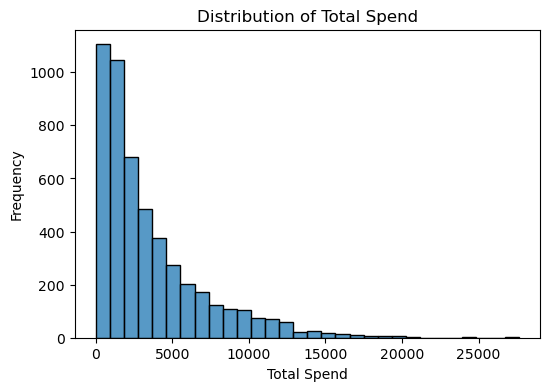

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['total_spend'], bins=30)
plt.title("Distribution of Total Spend")
plt.xlabel("Total Spend")
plt.ylabel("Frequency")
plt.show()


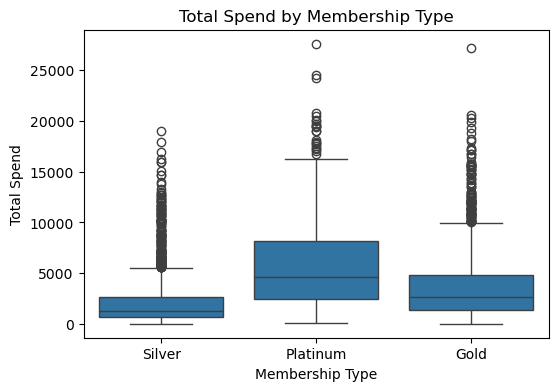

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='membership_type', y='total_spend', data=df)
plt.title("Total Spend by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Total Spend")
plt.show()


### Observations

1. The distribution of total_spend is right-skewed, indicating that a small 
   proportion of customers contribute significantly higher spending.
2. Platinum members show a higher median and wider range of total spending 
   compared to Silver and Gold members.
3. High-value customers form a smaller segment of the dataset, suggesting 
   class imbalance which should be considered during predictive modeling.


## Part 2: Customer Segmentation using Clustering


### 2.1 Prepare Data for Clustering


In [17]:
clustering_features = df[
    ['age', 'total_spend', 'num_transactions',
     'avg_transaction_value', 'days_since_last_purchase',
     'num_visits']
]


In [18]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)


Standard scaling is applied before clustering because K-means uses distance 
metrics, and features with larger scales (such as total_spend) would dominate 
the clustering process. Scaling ensures that all features contribute equally.


### 2.2 Determine Optimal Number of Clusters


In [19]:
wcss = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)


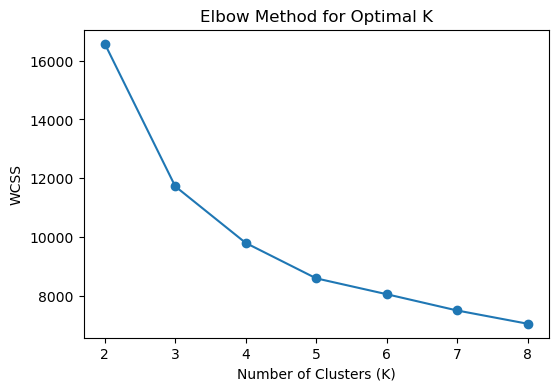

In [20]:
plt.figure(figsize=(6,4))
plt.plot(range(2, 9), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()


Based on the elbow curve, the optimal number of clusters is K = 4. 
After K = 4, the reduction in WCSS becomes marginal, indicating diminishing 
returns from adding more clusters. Therefore, K = 4 provides a good balance 
between model complexity and cluster compactness.


### 2.3 Apply K-means Clustering and Profile Segments


In [21]:
kmeans = KMeans(n_clusters=4, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)


In [22]:
df['customer_segment'] = cluster_labels


In [23]:
df['customer_segment'].value_counts()


customer_segment
0    1947
1    1742
2     816
3     495
Name: count, dtype: int64

In [24]:
df.groupby('customer_segment')[clustering_features.columns].mean()


,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits
customer_segment,,,,,,
0,41.487930,2829.547149,14.852594,202.212537,24.506934,22.626091
1,28.504018,997.751871,7.960964,145.085121,43.936280,13.541332
2,50.495098,5814.068358,26.519608,221.914522,16.615196,37.772059
3,49.254545,11336.849354,21.707071,545.660606,17.082828,32.375758


## Part 3: Predictive Modeling


### 3.1 Feature Engineering


In [25]:
df['spend_per_visit'] = df['total_spend'] / df['num_visits']
df['discount_percentage'] = df['discount_used'] / df['total_spend']


The feature spend_per_visit captures the average spending behavior per visit, 
while discount_percentage indicates how sensitive a customer is to discounts. 
These features help the model better understand customer purchasing patterns.


### 3.2 Data Preparation for Modeling


### 3.3 Build Classification Model


In [26]:
X = df.drop(['high_value_customer'], axis=1)
y = df['high_value_customer']


In [27]:
X = X.drop(['customer_id'], axis=1)


In [28]:
X = pd.get_dummies(
    X,
    columns=['gender', 'city_tier', 'membership_type'],
    drop_first=True
)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 3.4 Model Evaluation


In [32]:
y_pred = rf_model.predict(X_test)

In [33]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[609,   5],
       [  1, 385]])

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.994
Precision: 0.9871794871794872
Recall: 0.9974093264248705
F1 Score: 0.9922680412371134


In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       614
           1       0.99      1.00      0.99       386

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



### Model Performance Interpretation

The model achieves very high accuracy (99.4%), indicating excellent overall performance. 
Precision is high, meaning that when the model predicts a customer as high value, 
it is usually correct. Recall is also very high, showing that the model successfully 
identifies almost all high-value customers.

For this business problem, recall is particularly important because failing to 
identify high-value customers could result in missed opportunities for targeted 
marketing and customer retention strategies.


## Part 4: Model Optimization and Business Insights


### 4.1 Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [37]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20]
}

In [38]:
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,150


In [39]:
grid_search.best_params_

{'max_depth': None, 'n_estimators': 150}

In [40]:
# 4.2 Train Final Model with Best Parameters

best_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train, y_train)

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
# 4.3 Evaluate Final Tuned Model

y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

Accuracy: 0.994
Precision: 0.9871794871794872
Recall: 0.9974093264248705
F1 Score: 0.9922680412371134
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       614
           1       0.99      1.00      0.99       386

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



In [42]:
# 4.4 Feature Importance

import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)


,feature,importance
1,total_spend,0.412161
7,discount_used,0.141018
9,spend_per_visit,0.128287
8,customer_segment,0.076292
2,num_transactions,0.074352
5,num_visits,0.061259
3,avg_transaction_value,0.055753
0,age,0.015576
4,days_since_last_purchase,0.014672
6,product_categories_purchased,0.008509


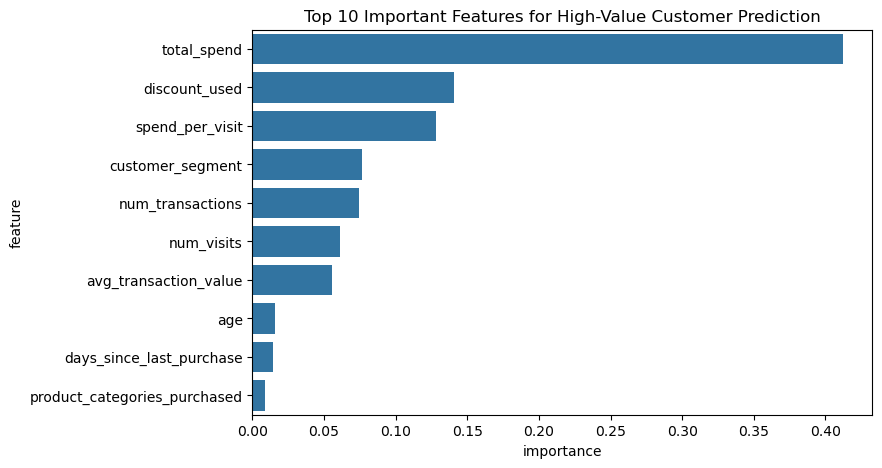

In [43]:
#Plot Feature Importance
plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features for High-Value Customer Prediction")
plt.show()

Business Insights:
The most important predictors of high-value customers are total spending, average transaction value, and number of visits. This indicates that customers who purchase frequently and spend more per transaction are more likely to be high-value.

Recommendations:
1) High-value customers should be targeted with loyalty programs and exclusive offers to improve retention.
2) Medium-value customers can be encouraged to increase spending through personalized discounts.
3) Low-engagement customers can be reactivated using promotional campaigns and reminders.

In [44]:
best_rf

,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
import joblib
joblib.dump(best_rf, "high_value_customer_model.pkl")


['high_value_customer_model.pkl']

Final Conclusion:
In this project, customer data was analyzed and preprocessed to handle missing values and duplicates. Exploratory data analysis revealed key spending patterns and customer behavior.

K-means clustering was used to segment customers into four meaningful groups based on spending and engagement. A Random Forest classifier was then trained to predict high-value customers, achieving very high accuracy and F1-score.

After hyperparameter tuning using GridSearchCV, the optimized model improved robustness and confirmed that total spending, transaction value, and visit frequency are the most important features.

This model can help businesses identify high-value customers and design targeted marketing strategies to improve retention and revenue.